In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def imp_inductor(frequency, L,C_par=0, DCR = 0):
    """
    Calculate the impedance of an inductor.

    Parameters:
    frequency (float): Frequency in Hz.
    L (float): Inductance in Henrys.
    C_par (float): Parasitic capacitance in Farads (default is 0).
    DCR (float): Direct current resistance in Ohms (default is 0).

    Returns:
    complex: Impedance of the inductor.
    """
    omega = 2 * np.pi * frequency

    Z_L = DCR + 1j * omega * L

    if C_par ==0:
        return Z_L

    Z_C = 1/(1j * omega * C_par)

    Z = (Z_L * Z_C) / (Z_L + Z_C)
    
    return Z


def imp_capacitor(frequency, C,ESL=0, ESR = 0):
    """
    Calculate the impedance of a capacitor.

    Parameters:
    frequency (float): Frequency in Hz.
    C (float): Capacitance in Farads.
    ESL (float): Equivalent Series Inductance in Henrys (default is 0).
    ESR (float): Equivalent Series Resistance in Ohms (default is 0).

    Returns:
    complex: Impedance of the capacitor.
    """
    omega = 2 * np.pi * frequency
        
    Z_C = 1 / (1j * omega * C)

    if ESL == 0:
        return Z_C + ESR

    Z_L = 1j * omega * ESL

    Z = Z_C + ESR + Z_L

    return Z


def resonant_frequency(L, C):
    """
    Calculate the resonant frequency of an LC circuit.

    Parameters:
    L (float): Inductance in Henrys.
    C (float): Capacitance in Farads.

    Returns:
    float: Resonant frequency in Hz.
    """
    return 1 / (2 * np.pi * np.sqrt(L * C))


def from_SRF_to_C_par(SRF, L):
    """
    Calculate the parasitic capacitance from the self-resonant frequency and inductance.

    Parameters:
    SRF (float): Self-resonant frequency in Hz.
    L (float): Inductance in Henrys.

    Returns:
    float: Parasitic capacitance in Farads.
    """

    C_par = 1 / ((2 * np.pi * SRF) ** 2 * L)
    return C_par


def from_SRF_to_ESL(SRF, C):
    """
    Calculate the equivalent series inductance from the self-resonant frequency and capacitance.

    Parameters:
    SRF (float): Self-resonant frequency in Hz.
    C (float): Capacitance in Farads.

    Returns:
    float: Equivalent series inductance in Henrys.
    """
    ESL = 1 / ((2 * np.pi * SRF) ** 2 * C)
    return ESL


def AC_current_ratio(I_tot,Z_DC,Z_AC):
    """
    Calculate the AC current ratio.

    Parameters:
    I_tot (float): Total current in Amperes.
    Z_DC (complex): Impedance of the DC path.
    Z_AC (complex): Impedance of the AC path.

    Returns:
    float: AC current ratio.
    """
    return I_tot * Z_DC / (Z_DC + Z_AC)

def DC_current_ratio(I_tot,Z_DC,Z_AC):
    """
    Calculate the DC current ratio.

    Parameters:
    I_tot (float): Total current in Amperes.
    Z_DC (complex): Impedance of the DC path.
    Z_AC (complex): Impedance of the AC path.

    Returns:
    float: DC current ratio.
    """
    return I_tot * Z_AC / (Z_DC + Z_AC)


def add_impedance_parallel(Z1, Z2):
    """
    Calculate the total impedance of two impedances in parallel.

    Parameters:
    Z1 (complex): Impedance 1.
    Z2 (complex): Impedance 2.

    Returns:
    complex: Total impedance of the two impedances in parallel.
    """
    return (Z1 * Z2) / (Z1 + Z2)

Resonant frequency of 0.1 mH inductor with 1 pF: 13.00 MHz
Resonant frequency of 100 mH inductor with 31 pF: 0.09 MHz
Resonant frequency of 14 µF capacitor with 0.3 nH ESL: 2.32 MHz


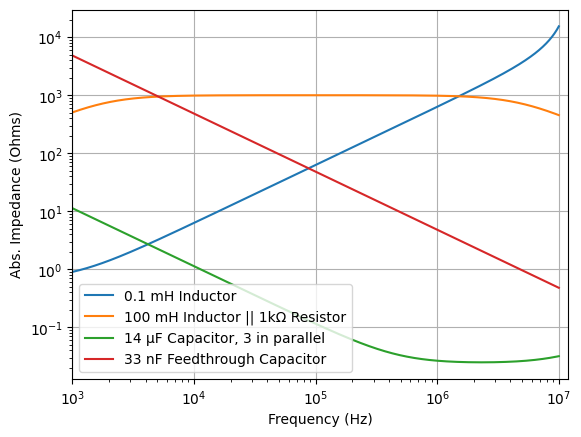

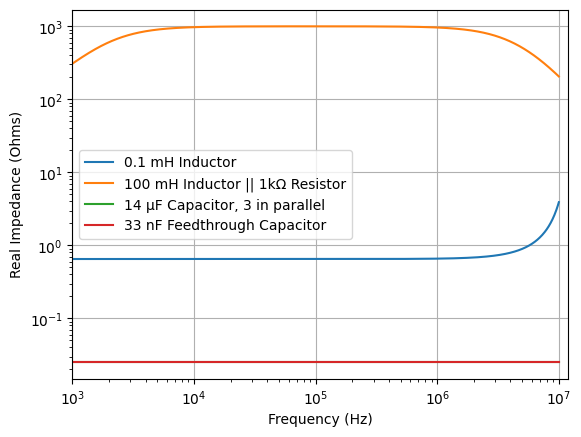

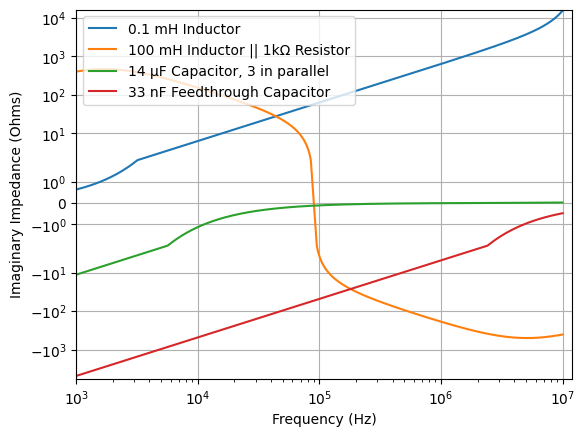

In [12]:
frequency = np.logspace(3, 7, 1000)  # Frequency range from 1 kHz to 10 MHz


### Inductor values
inductor_small = 100e-6  # 100 µH
SRF_small_inductor = 13e6  # 13 MHz
inductor_small_DCR = 0.65  # 0.65 Ohm
# inductor_small = 1e-3  # 1 mH
# SRF_small_inductor = 1.6e6  # 1.6 MHz
# inductor_small_DCR = 13  # 0.65 Ohm

# inductor_large = 33e-3  # 33 mH
# SRF_large_inductor = 280e3  # 280 kHz
# inductor_large_DCR = 110  # 110 Ohm
inductor_large = 100e-3  # 100 mH
SRF_large_inductor = 90e3  # 90 kHz
inductor_large_DCR = 82  # 57 Ohm



# induct_EPC_small = 1e-12  # 1 pF 
induct_EPC_small = from_SRF_to_C_par(SRF_small_inductor, inductor_small)  # Calculate parasitic capacitance from SRF and inductance

# induct_EPC_large = 10e-12  # 10 pF 
induct_EPC_large = from_SRF_to_C_par(SRF_large_inductor, inductor_large)  # Calculate parasitic capacitance from SRF and inductance


### Impedance damper 
R_damp_small = 1e3  # 1 kOhm parallel damping resistor
R_damp_large = 1e3  # 1 kOhm parallel damping resistor


### Capacitor values
capacitance_per_capacitor = 4.7e-6  # 5 µF
no_capacitors_in_parallel = 3  # Number of capacitors in parallel
capacitors_in_parallel = no_capacitors_in_parallel * capacitance_per_capacitor  # Total capacitance in parallel

capac_ESL = 1e-9/no_capacitors_in_parallel  # 1 nH per capacitor, divided by the number of capacitors in parallel

cap_ESR = 0.01/no_capacitors_in_parallel  # 10 mOhm per capacitor, divided by the number of capacitors in parallel

### Resonant frequencies:
resonant_freq_inductor_small = resonant_frequency(inductor_small, induct_EPC_small)
resonant_freq_inductor_large = resonant_frequency(inductor_large, induct_EPC_large)

print(f"Resonant frequency of {inductor_small*1e3:.1f} mH inductor with {induct_EPC_small*1e12:.0f} pF: {resonant_freq_inductor_small*1e-6:.2f} MHz")
print(f"Resonant frequency of {inductor_large*1e3:.0f} mH inductor with {induct_EPC_large*1e12:.0f} pF: {resonant_freq_inductor_large*1e-6:.2f} MHz")

resonant_freq_capacitor = resonant_frequency(capacitors_in_parallel, capac_ESL)

print(f"Resonant frequency of {capacitors_in_parallel*1e6:.0f} µF capacitor with {capac_ESL*1e9:.1f} nH ESL: {resonant_freq_capacitor*1e-6:.2f} MHz")

### Digital multimeter
impedance_DMM = 10e6  # 10 MOhm

### Feedthrough capacitor
cap_feed = 33e-9 # 33 nF,
cap_SRF = 150e6 # 150 MHz (guess),
cap_ESR = 0.025 # 25 mOhm (guess)

# cap_feed = 10e-12 # 10 pF
# cap_SRF = 10e9 # 150 MHz (guess),
# cap_ESR = 0.005 # 5 mOhm (guess)

# cap_feed = 200e-12 # 200 pF
# cap_SRF = 2e9 # 300 MHz (guess),
# cap_ESR = 0.008 # 8 mOhm (guess)

# cap_feed = 1e-9 # 1 nF
# cap_SRF = 1e9 # 300 MHz (guess),
# cap_ESR = 0.015 # 20 mOhm (guess)

ESL_feed = from_SRF_to_ESL(cap_SRF, cap_feed)  # Calculate ESL from SRF and capacitance

impedance_feed = imp_capacitor(frequency, cap_feed, ESL_feed, cap_ESR)  # Feedthrough capacitor with calculated ESL and ESR




### Impedance calculations

impedance_inductor_small = imp_inductor(frequency, inductor_small, induct_EPC_small, inductor_small_DCR)
impedance_inductor_large = imp_inductor(frequency, inductor_large, induct_EPC_large, inductor_large_DCR)

# impedance_inductor_small = add_impedance_parallel(impedance_inductor_small, R_damp_small)  # Add parallel damping resistor to the small inductor
impedance_inductor_large = add_impedance_parallel(impedance_inductor_large, R_damp_large)  # Add parallel damping resistor to the large inductor

# mask_small = frequency < resonant_freq_inductor_small
# mask_large = frequency < resonant_freq_inductor_large
# mask_capacitor = frequency < resonant_freq_capacitor


impedance_capacitor = imp_capacitor(frequency, capacitors_in_parallel, capac_ESL, cap_ESR)


### Plotting

plt.plot(frequency, np.abs(impedance_inductor_small), label=f'{inductor_small*1e3:.1f} mH Inductor')
plt.plot(frequency, np.abs(impedance_inductor_large), label=f'{inductor_large*1e3:.0f} mH Inductor || 1kΩ Resistor')
plt.plot(frequency, np.abs(impedance_capacitor), label=f'{capacitors_in_parallel*1e6:.0f} µF Capacitor, {no_capacitors_in_parallel} in parallel')
plt.plot(frequency, np.abs(impedance_feed), label=f'{cap_feed*1e9:.0f} nF Feedthrough Capacitor')
# plt.vlines(resonant_freq_inductor_small, 0, np.max(np.abs(reactance_inductor_small)), color='blue', linestyle='--', label=f'Resonant freq {resonant_freq_inductor_small*1e-6:.2f} MHz')
# plt.vlines(resonant_freq_inductor_large, 0, np.max(np.abs(reactance_inductor_large)), color='orange', linestyle='--', label=f'Resonant freq {resonant_freq_inductor_large*1e-6:.2f} MHz')
# plt.vlines(resonant_freq_capacitor, 0, np.max(np.abs(reactance_capacitor)), color='green', linestyle='--', label=f'Resonant freq {resonant_freq_capacitor*1e-6:.2f} MHz')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Abs. Impedance (Ohms)')

plt.xlim([1e3, 1.2e7])
plt.grid()



### Plot real and imaginary parts of the impedance
plt.figure()
plt.plot(frequency, np.real(impedance_inductor_small), label=f'{inductor_small*1e3:.1f} mH Inductor')
plt.plot(frequency, np.real(impedance_inductor_large), label=f'{inductor_large*1e3:.0f} mH Inductor || 1kΩ Resistor')
plt.plot(frequency, np.real(impedance_capacitor), label=f'{capacitors_in_parallel*1e6:.0f} µF Capacitor, {no_capacitors_in_parallel} in parallel')
plt.plot(frequency, np.real(impedance_feed), label=f'{cap_feed*1e9:.0f} nF Feedthrough Capacitor')
# plt.vlines(resonant_freq_inductor_small, 0, np.max(np.abs(reactance_inductor_small)), color='blue', linestyle='--', label=f'Resonant freq {resonant_freq_inductor_small*1e-6:.2f} MHz')
# plt.vlines(resonant_freq_inductor_large, 0, np.max(np.abs(reactance_inductor_large)), color='orange', linestyle='--', label=f'Resonant freq {resonant_freq_inductor_large*1e-6:.2f} MHz')
# plt.vlines(resonant_freq_capacitor, 0, np.max(np.abs(reactance_capacitor)), color='green', linestyle='--', label=f'Resonant freq {resonant_freq_capacitor*1e-6:.2f} MHz')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Real Impedance (Ohms)')

plt.xlim([1e3, 1.2e7])
plt.grid()


plt.figure()
plt.plot(frequency, np.imag(impedance_inductor_small), label=f'{inductor_small*1e3:.1f} mH Inductor')
plt.plot(frequency, np.imag(impedance_inductor_large), label=f'{inductor_large*1e3:.0f} mH Inductor || 1kΩ Resistor')
plt.plot(frequency, np.imag(impedance_capacitor), label=f'{capacitors_in_parallel*1e6:.0f} µF Capacitor, {no_capacitors_in_parallel} in parallel')
plt.plot(frequency, np.imag(impedance_feed), label=f'{cap_feed*1e9:.0f} nF Feedthrough Capacitor')
# plt.vlines(resonant_freq_inductor_small, 0, np.max(np.abs(reactance_inductor_small)), color='blue', linestyle='--', label=f'Resonant freq {resonant_freq_inductor_small*1e-6:.2f} MHz')
# plt.vlines(resonant_freq_inductor_large, 0, np.max(np.abs(reactance_inductor_large)), color='orange', linestyle='--', label=f'Resonant freq {resonant_freq_inductor_large*1e-6:.2f} MHz')
# plt.vlines(resonant_freq_capacitor, 0, np.max(np.abs(reactance_capacitor)), color='green', linestyle='--', label=f'Resonant freq {resonant_freq_capacitor*1e-6:.2f} MHz')
plt.xscale('log')
plt.yscale('symlog')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Imaginary Impedance (Ohms)')

plt.xlim([1e3, 1.2e7])
# plt.ylim([-1e1, 1e5])
plt.grid()

In [13]:
induct_EPC_large*1e12

31.27197025998079

Text(0.5, 1.0, 'Large inductor only')

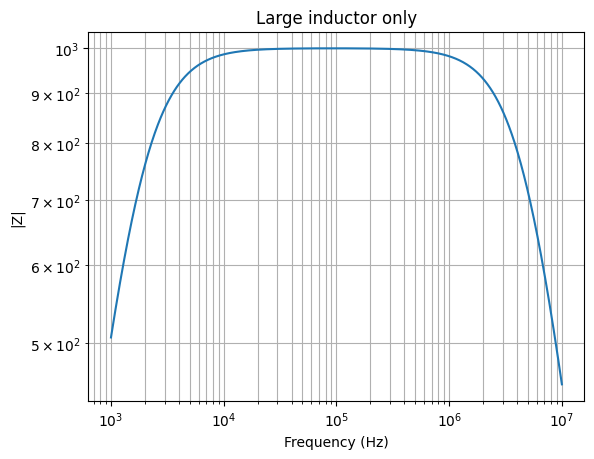

In [14]:
Z_DC = impedance_inductor_large

plt.figure()
plt.loglog(frequency, np.abs(Z_DC))
plt.grid(True, which='both')
plt.xlabel('Frequency (Hz)')
plt.ylabel('|Z|')
plt.title('Large inductor only')

Text(0, 0.5, 'Ratio (dB)')

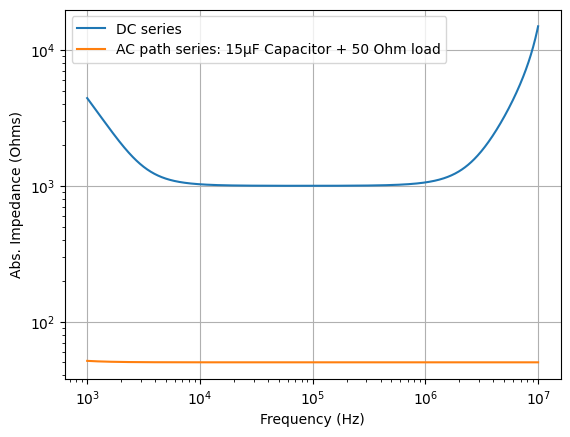

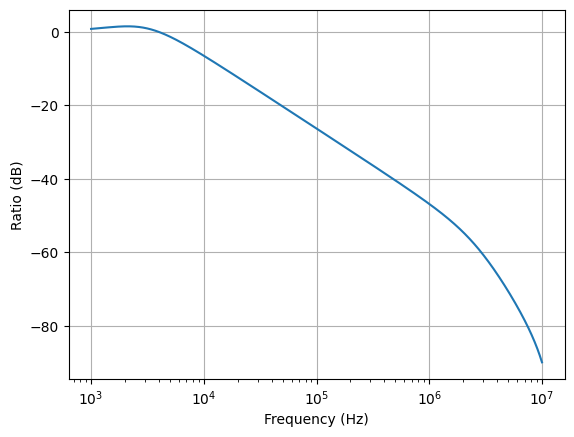

In [15]:

Z_load =  add_impedance_parallel(impedance_feed, impedance_DMM)

Z_DC = impedance_inductor_large + impedance_inductor_small + Z_load #DC path: Large inductor + Feedthrough capacitor + Small inductor

Z_AC = impedance_capacitor + 50 #Since we have the ESA with 50Ohm input impedance in series

plt.loglog(frequency, np.abs(Z_DC), label=f'DC series') # : {cap_feed*1e9:.0f} nF Feedthrough Capacitor || DMM 10 MΩ')
plt.loglog(frequency, np.abs(Z_AC), label='AC path series: 15µF Capacitor + 50 Ohm load')
plt.legend()
plt.grid()
plt.ylabel('Abs. Impedance (Ohms)')
plt.xlabel('Frequency (Hz)')
# plt.yscale('symlog')

plt.figure()
H = Z_load/(Z_DC)
H_dB = 20*np.log10(np.abs(H))
plt.semilogx(frequency, H_dB)   
# plt.loglog(frequency, np.abs(H))
plt.grid()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Ratio (dB)')


Text(0.5, 0, 'Frequency (Hz)')

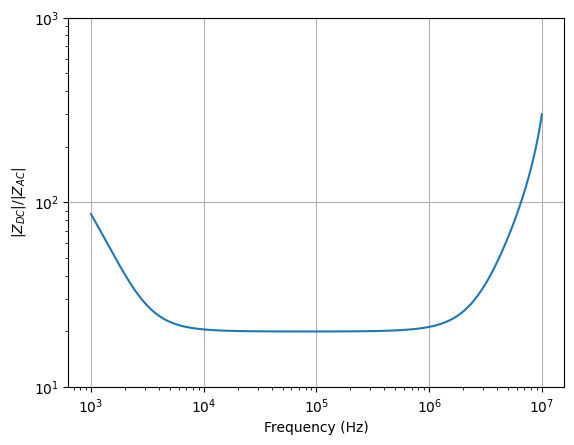

In [16]:
ratio = np.abs(Z_DC)/np.abs(Z_AC)

plt.figure()
plt.loglog(frequency, ratio)
plt.grid()
plt.ylim([1e1,1e3])
plt.ylabel(r'$|Z_{DC}|/|Z_{AC}|$')
plt.xlabel('Frequency (Hz)')

In [17]:
# I_AC_fraction = np.abs(AC_current_ratio(1, Z_DC, Z_AC))
# I_DC_fraction = np.abs(DC_current_ratio(1, Z_DC, Z_AC))

# total = I_AC_fraction + I_DC_fraction

# I_AC_norm= I_AC_fraction/total
# I_DC_norm= I_DC_fraction/total

# plt.figure()

# plt.semilogx(
#     frequency,
#     I_AC_norm,
#     label='To ESA'
# )

# plt.semilogx(
#     frequency,
#     I_DC_norm,
#     label='To DC path'
# )

# plt.ylabel('Signal fraction [%]')
# plt.xlabel('Frequency (Hz)')
# plt.grid()
# plt.legend()
# plt.ylim([0.9,1])

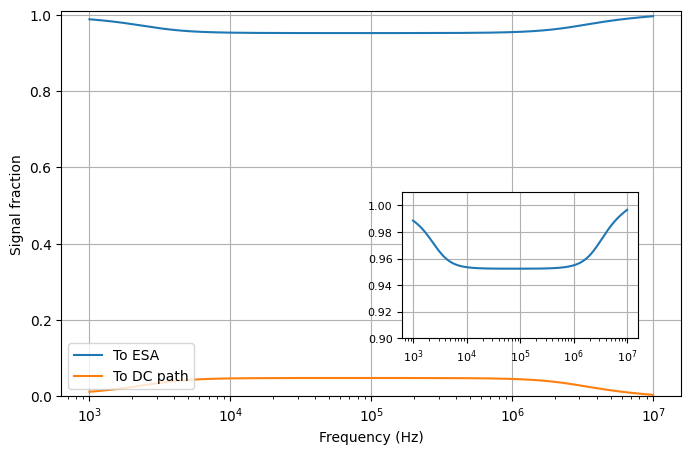

In [18]:
# ...existing code...
I_AC_fraction = np.abs(AC_current_ratio(1, Z_DC, Z_AC))
I_DC_fraction = np.abs(DC_current_ratio(1, Z_DC, Z_AC))

total = I_AC_fraction + I_DC_fraction

I_AC_norm = I_AC_fraction / total
I_DC_norm = I_DC_fraction / total

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(frequency, I_AC_norm, label='To ESA')
ax.semilogx(frequency, I_DC_norm, label='To DC path')

ax.set_ylabel('Signal fraction')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylim(0, 1.01)
ax.grid(True)
ax.legend(loc='lower left')

# Inset zoom: 0.9 to 1.0
ax_inset = ax.inset_axes([0.55, 0.15, 0.38, 0.38])
ax_inset.semilogx(frequency, I_AC_norm)
ax_inset.semilogx(frequency, I_DC_norm)
ax_inset.set_ylim(0.90, 1.01)
ax_inset.grid(True)

# Optional: make inset ticks smaller
ax_inset.tick_params(labelsize=8)
# ...existing code...